## Steel Plate Analysis Technical Report
Spencer Mundel and Damon Lewis

### Dataset Description
|                | Steel Plate Dataset |
|----------------|---------------------|
| Instances      | 1941                |
| Unique Classes | 7                   |
| Attributes     | 27                  |

The dataset does not contain any missing values. Most of the data is continous, with only the steel type values (`TypeOfSteel_A300` and `TypeOfSteel_A400`) being categorical true/false, which is represented as 0/1. 

In [22]:
import copy
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mysklearn.mypytable import MyPyTable
from mysklearn.myutils import *
from mysklearn.myclassifiers import *

## Data Cleaning

Complete data cleaning steps can be found in the [Data Cleaning Notebook](data_cleaning.ipynb).

Only a small amount of cleaning was done. The classes were converted from one-hot encoding to categorical values to work better with our EDA and models. We also created a normalized version of the data using the z-score method for later use by PCA and KNN.

In [23]:
CLASSES = ["Pastry","Z_Scratch","K_Scratch","Stains","Dirtiness","Bumps","Other_Faults"]
CLASS_HEADER = "Class"

data = MyPyTable().load_from_file("input_data/plate-data-clean.csv")
features = copy.deepcopy(data.column_names)
features.remove(CLASS_HEADER)

## EDA

Complete EDA and all graphs can be seen in our [EDA Notebook](EDA.ipynb).

We first examined the distributions of classes to identify any class imbalance. We examined the distributions of all attributes to try and identify trends or potential obvious relationships.

One of our main forms of EDA was to create boxplots for each attribute, grouped by class. Our goal was to identify attributes that had distributions that varied significantly between classes, making them more useful and informative for classification.

#### Count Distributions for All Attributes

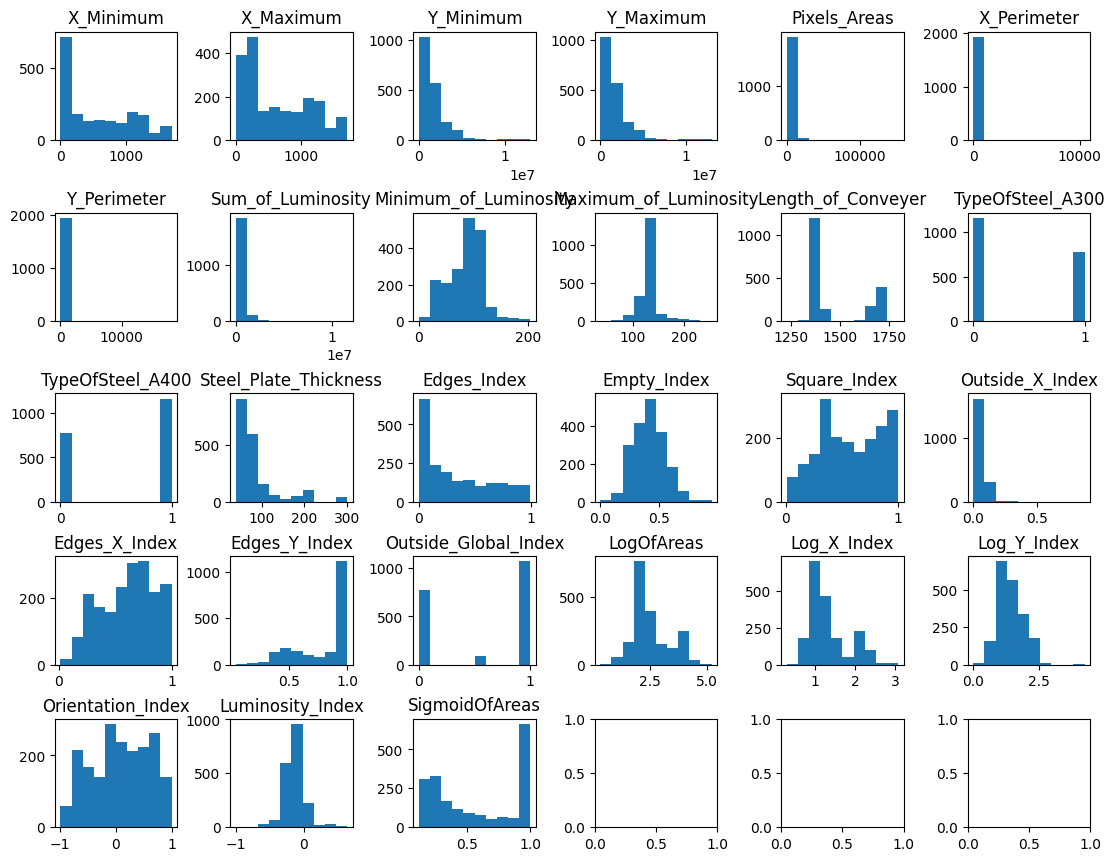

In [24]:
col_count = 6

tmp_classes = copy.deepcopy(data.column_names)
tmp_classes.remove('Class')
tmp_fig, ax = plt.subplots((len(tmp_classes)//col_count)+1, col_count, layout='constrained', figsize=(8,8))
tmp_fig.set_size_inches(11, 8.5)
for col in range(len(tmp_classes)):
    tmp = ax.flat[col]
    tmp.hist(data.get_column(data.column_names[col]))
    tmp.set_title(data.column_names[col])
plt.savefig('./media/dist.png')

#### Occurrences for Each Class

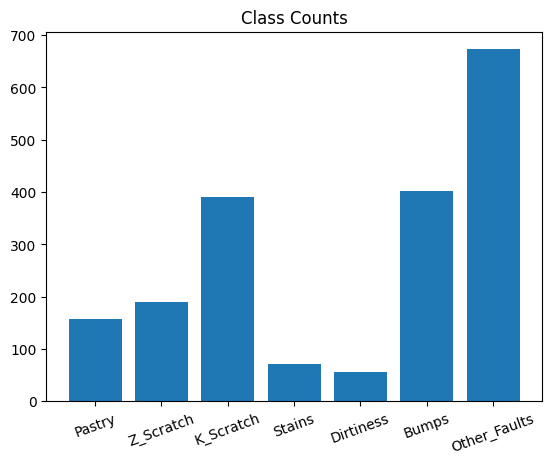

In [25]:
counts = {k: 0 for k in CLASSES}
for result in data.get_column('Class'):
    counts[result]+=1

fig, ax = plt.subplots()
ax.set_title("Class Counts")
ax.bar(counts.keys(), counts.values())
ax.tick_params('x', rotation=20)
fig.savefig('./media/counts.png')

### Model Testing and Results

In [26]:
normalized = MyPyTable().load_from_file("input_data/plate-data-normal.csv")
binned = MyPyTable(data.column_names, data.data)

for feature in features:
    if feature == "TypeOfSteel_A300" or feature == "TypeOfSteel_A400":
        continue

    col_values = data.get_column(feature)
    binned_col = equal_width_bin(col_values, 10)
    binned.replace_column(feature, binned_col)

#### Decision Tree

In [27]:
stratified_kfold_tester(MyDecisionTreeClassifier(len(features)),
                                binned,
                                CLASS_HEADER,
                                CLASSES,
                                10)

Setup complete
Confusion Matrix
                Pastry    Z_Scratch    K_Scratch    Stains    Dirtiness    Bumps    Other_Faults
------------  --------  -----------  -----------  --------  -----------  -------  --------------
Pastry               0            0           42         0            0        1             115
Z_Scratch            0            0          129         0            0        0              61
K_Scratch            0            0          338         0            0        8              45
Stains               0            0            0         0            0        8              64
Dirtiness            0            0            4         0            0       11              40
Bumps                0            0           48         0            0       26             328
Other_Faults         0            0          158         0            0       43             472
accuracy: 0.8373445204975345
precision: 0.16538487858712111
f1 score: 0.17689217635985477
recal

### KNN

In [28]:
stratified_kfold_tester(MyKNeighborsClassifier(n_neighbors=3),
                                normalized,
                                CLASS_HEADER,
                                CLASSES,
                                10)

Setup complete
Confusion Matrix
                Pastry    Z_Scratch    K_Scratch    Stains    Dirtiness    Bumps    Other_Faults
------------  --------  -----------  -----------  --------  -----------  -------  --------------
Pastry              69            3            1         0            1       43              41
Z_Scratch            3          163            5         0            0        6              13
K_Scratch            1            0          374         2            0        3              11
Stains               0            0            0        67            0        3               2
Dirtiness            4            0            0         0           45        2               4
Bumps               17            8            2         1            4      258             112
Other_Faults        22           24           22         6           13      152             434
accuracy: 0.9218370501214396
precision: 0.7422190339653673
f1 score: 0.7456439673555969
recall:

#### KNN with PCA Component Analysis

In [29]:
data_pca = MyPyTable().load_from_file("input_data/plate-data-pca.csv")

features = deepcopy(data_pca.column_names)
features.pop(features.index(CLASS_HEADER))

stratified_kfold_tester(MyKNeighborsClassifier(n_neighbors=3),
                                data_pca,
                                CLASS_HEADER,
                                CLASSES,
                                10)

Setup complete
Confusion Matrix
                Pastry    Z_Scratch    K_Scratch    Stains    Dirtiness    Bumps    Other_Faults
------------  --------  -----------  -----------  --------  -----------  -------  --------------
Pastry              62            6            1         0            4       37              48
Z_Scratch            2          141            8         0            2       11              26
K_Scratch            1            0          373         2            0        4              11
Stains               0            0            0        65            0        5               2
Dirtiness            2            2            0         0           44        5               2
Bumps               19           10            0         0            7      255             111
Other_Faults        21           36           20         8           11      150             427
accuracy: 0.9155074703760947
precision: 0.7101659485251988
f1 score: 0.7121041294808365
recall:

#### Random Forest

In [30]:
stratified_kfold_tester(MyRandomForestClassifier(10, 5, 5),
                                binned,
                                CLASS_HEADER,
                                CLASSES,
                                10)

Setup complete
Confusion Matrix
                Pastry    Z_Scratch    K_Scratch    Stains    Dirtiness    Bumps    Other_Faults
------------  --------  -----------  -----------  --------  -----------  -------  --------------
Pastry               0            0           42         0            0       10             106
Z_Scratch            0            0          129         0            0        1              60
K_Scratch            0            0          338         0            0       10              43
Stains               0            0            0         0            0        8              64
Dirtiness            0            0            4         0            0       13              38
Bumps                0            0           48         0            0       29             325
Other_Faults         0            0          158         0            0       48             467
accuracy: 0.8370501214396114
precision: 0.162455084132241
f1 score: 0.17803346944421802
recall:

#### Clustered Random Forest

In [31]:
stratified_kfold_tester(MyClusteredRandomForestClassifier(10, 5, 5, 2),
                                data,
                                CLASS_HEADER,
                                CLASSES,
                                10)

Setup complete
Confusion Matrix
                Pastry    Z_Scratch    K_Scratch    Stains    Dirtiness    Bumps    Other_Faults
------------  --------  -----------  -----------  --------  -----------  -------  --------------
Pastry               0           11           12         0            0       27             108
Z_Scratch            0          138           13         0            0        1              38
K_Scratch            0            0          257         0            0       27             107
Stains               0            0            0         0            0        3              69
Dirtiness            0            0            2         0            0        6              47
Bumps                0           16            9         2            0       95             280
Other_Faults         3           36           25         0            0       71             538
accuracy: 0.8656068300581438
precision: 0.3372900305720051
f1 score: 0.32999637529408676
recall